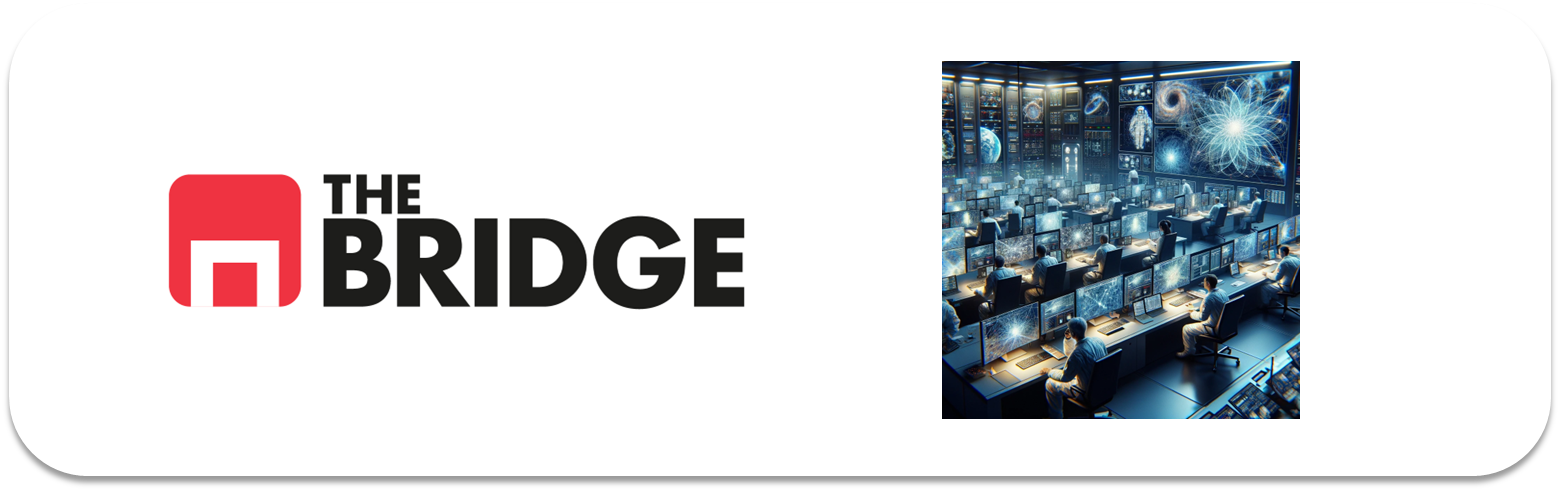

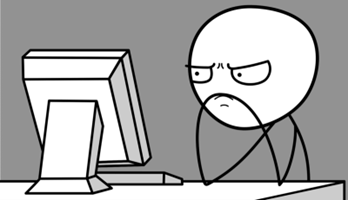

Para ejercitarte y afianzar lo aprendido sobre **Transfer Learning y Fine-tuning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
# --- Datos y ficheros ---
import os
import gc
import time
import numpy as np
import pandas as pd

# --- Imagenes ---
from skimage.io import imread
import cv2

# --- Visualizacion ---
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

# --- sklearn ---
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# --- Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization

import warnings
warnings.filterwarnings("ignore")

SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.15.0


## Apple 360

En este conjunto de ejercicios vas a montar un clasificador de manzanas mediante un dataset de imágenes. El dataset se compone de 13 tipos diferentes con aproximadamente unas 200 imágenes por cada tipo. Tendrás que montar un modelo de deep learning que utilice **transfer learning**. Se sugiere empezar con una red ResNet50 con imagenet.

El dataset original proviene del [concurso de Kaggle Fruits 360](https://www.kaggle.com/moltean/fruits), pero adaptado para la clasificación de una menor cantidad de casos (sólo las manzanas).


### Ejercicio 1

Crea los juegos de X,y para train y test a partir de los datos teninendo en cuenta su distribución, para ello tendrás que explorar las estructura. Crea un juego Train,test para resolución 32x32 y un juego de test adicional para 224x224. Es decir tendras que tener un X_train, X_test para 32x32 y un X_test adicional a 224x224

Primero exploramos la estructura, que es lo que pide el enunciado ("tendrás que
explorar las estructura").

In [2]:
ROOT_PATH = "./data/apples/"
TRAIN_PATH = ROOT_PATH + "Train/"
TEST_PATH = ROOT_PATH + "Test/"

for ruta, nombre in [(TRAIN_PATH, "TRAIN"), (TEST_PATH, "TEST")]:
    clases = sorted(os.listdir(ruta))
    total = 0
    print(f"--- {nombre} ---")
    for c in clases:
        n = len(os.listdir(os.path.join(ruta, c)))
        total += n
        print(f"   {c:14} {n:5}")
    print(f"   {'TOTAL':14} {total:5} imagenes en {len(clases)} clases\n")

--- TRAIN ---
   Braeburn         492
   CrimsonSnow      444
   Golden1          480
   Golden2          492
   Golden3          481
   GrannySmith      492
   PinkLady         456
   Red1             492
   Red2             492
   Red3             429
   RedDelicious     490
   RedYellow1       492
   RedYellow2       672
   TOTAL           6404 imagenes en 13 clases

--- TEST ---
   Braeburn         164
   CrimsonSnow      148
   Golden1          160
   Golden2          164
   Golden3          161
   GrannySmith      164
   PinkLady         152
   Red1             164
   Red2             164
   Red3             144
   RedDelicious     166
   RedYellow1       164
   RedYellow2       219
   TOTAL           2134 imagenes en 13 clases



**13 variedades de manzana**, unas 6.400 imágenes de train y 2.100 de test. Es un
problema de **clasificación fina** (*fine-grained*): todas las clases son el mismo
objeto, una manzana, y lo que las diferencia son matices de color y forma. Eso lo
hace bastante más difícil que distinguir un perro de un gato.

Vemos el tamaño original antes de redimensionar:

In [3]:
ejemplo = os.path.join(TRAIN_PATH, "Braeburn")
for f in sorted(os.listdir(ejemplo))[:3]:
    print(f, imread(os.path.join(ejemplo, f)).shape)

0_100.jpg (100, 100, 3)
100_100.jpg (100, 100, 3)
101_100.jpg (100, 100, 3)


Originales de 100x100. El enunciado pide **dos juegos de datos**:

* `X_train` y `X_test` a **32x32**, que usaremos para casi todo.
* un `X_test` adicional a **224x224**, que es el tamaño nativo de ResNet50 y hace
  falta para el zero-shot del Ejercicio 6 (con `include_top=True` la red solo acepta
  224x224).

In [4]:
def read_data(directorio, reshape_dim=(32, 32)):
    """Lee las imagenes de un directorio etiquetandolas con el nombre de su carpeta.

    Args:
        directorio: ruta que contiene una subcarpeta por clase.
        reshape_dim: tupla (ancho, alto) al que se redimensionan las imagenes.

    Returns:
        X (array de imagenes), y (array de etiquetas de texto)
    """
    X = []
    y = []
    for folder in sorted(os.listdir(directorio)):
        if os.path.isdir(os.path.join(directorio, folder)):
            for file in os.listdir(os.path.join(directorio, folder)):
                image = imread(os.path.join(directorio, folder, file))
                image = cv2.resize(image, reshape_dim)
                X.append(image)
                y.append(folder)

    return np.array(X), np.array(y)

In [5]:
t0 = time.time()

# Juego principal a 32x32
X_train, y_train = read_data(TRAIN_PATH, (32, 32))
X_test, y_test = read_data(TEST_PATH, (32, 32))

# Juego adicional de test a 224x224, solo para el zero-shot del Ejercicio 6
X_test_224, y_test_224 = read_data(TEST_PATH, (224, 224))

print(f"Carga: {time.time() - t0:.0f}s\n")
print("X_train     :", X_train.shape, f"{X_train.nbytes/1e6:6.1f} MB")
print("X_test      :", X_test.shape, f"{X_test.nbytes/1e6:6.1f} MB")
print("X_test_224  :", X_test_224.shape, f"{X_test_224.nbytes/1e6:6.1f} MB")

Carga: 28s

X_train     : (6404, 32, 32, 3)   19.7 MB
X_test      : (2134, 32, 32, 3)    6.6 MB
X_test_224  : (2134, 224, 224, 3)  321.2 MB


Ojo al salto de memoria: el mismo test ocupa **49 veces más** a 224x224 que a 32x32
(224² / 32² = 49). Es la razón por la que el enunciado nos hace trabajar a 32x32.

**NOTA:** A partir de aquí emplea siempre el X_train, X_test de 32x32 salvo en el ejercicio que se te diga lo contrario.

### Ejercicio 2

Haz una visualización de algunos de los datos. Crea una función que te ayude con ello.

Creamos la función de visualización, adaptada del workout (las imágenes son en color,
así que sin `cmap`).

In [6]:
def plot_imagenes(imagenes, etiquetas=None, n_cols=5, titulo=None):
    """Pinta un conjunto de imagenes en una rejilla, con su etiqueta encima."""
    n_filas = (len(imagenes) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_filas * 2.3))

    for indice, imagen in enumerate(imagenes):
        plt.subplot(n_filas, n_cols, indice + 1)
        plt.imshow(imagen)
        plt.axis("off")
        if etiquetas is not None:
            plt.title(etiquetas[indice], fontsize=9)

    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

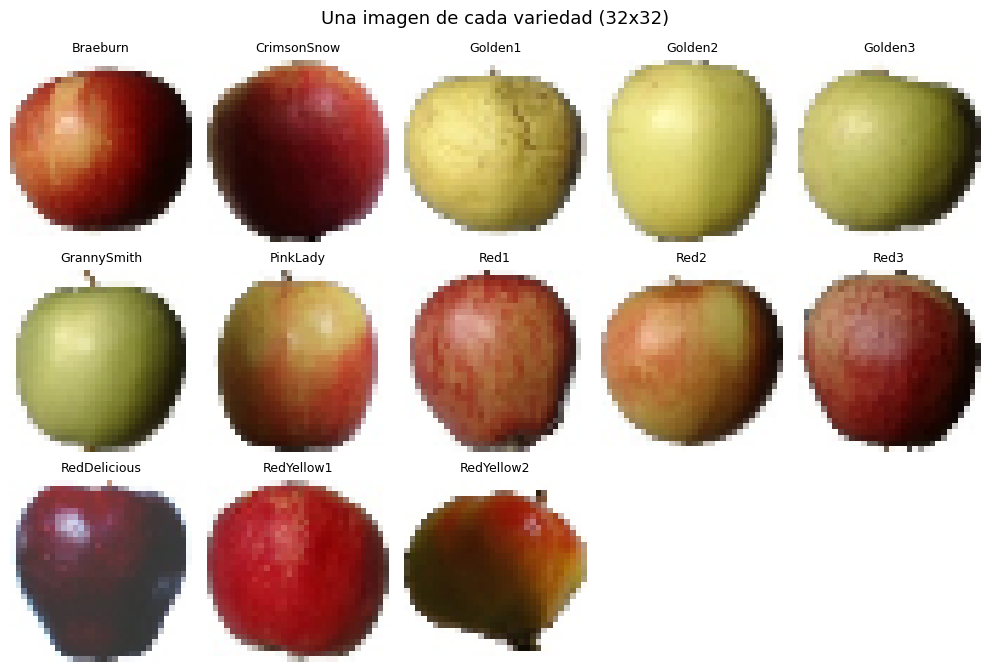

In [7]:
CLASES = sorted(np.unique(y_train))

# Una imagen de cada clase, para ver a qué nos enfrentamos
indices = [np.where(y_train == c)[0][0] for c in CLASES]
plot_imagenes(X_train[indices], list(CLASES), n_cols=5,
              titulo="Una imagen de cada variedad (32x32)")

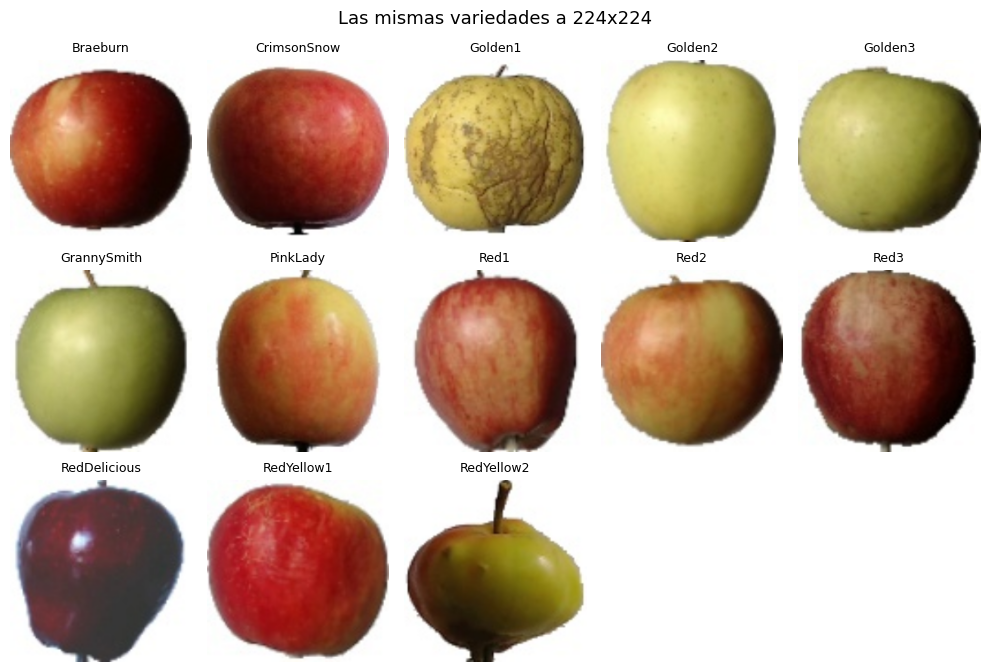

In [8]:
# La misma comparación a 224x224, donde sí se aprecian los matices
indices_224 = [np.where(y_test_224 == c)[0][0] for c in CLASES]
plot_imagenes(X_test_224[indices_224], list(CLASES), n_cols=5,
              titulo="Las mismas variedades a 224x224")

**Observaciones importantes de la visualización**

1. Las imágenes están **muy limpias**: una manzana centrada sobre fondo blanco, bien
   iluminada, sin oclusiones. Es un dataset de laboratorio, no de fotos naturales.
   Eso hace el problema más fácil de lo que parecería.
2. Pero es **fine-grained**: comparando `Golden1`, `Golden2` y `Golden3`, o `Red1`,
   `Red2` y `Red3`, las diferencias son mínimas incluso a 224x224. Algunas parecen
   la misma manzana girada.
3. A 32x32 se pierde buena parte del matiz de color y textura de la piel, que es
   justo lo que distingue las variedades. Ahí es donde el modelo va a sufrir.

### Ejercicio 3

Completa el miniEDA habitual con imágenes y escoge una métrica para el modelo.

El miniEDA habitual: distribución del target con `bootcampviztools`.

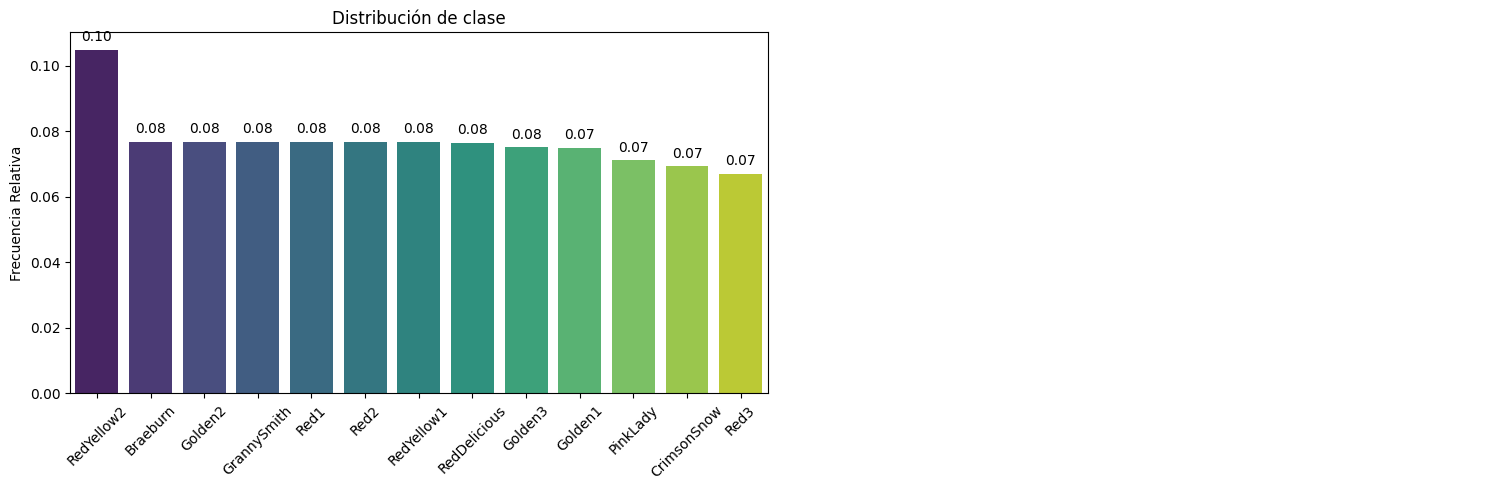

In [9]:
df_train = pd.DataFrame({"clase": y_train})
df_test = pd.DataFrame({"clase": y_test})

bt.pinta_distribucion_categoricas(df_train, ["clase"], relativa=True, mostrar_valores=True)

In [10]:
print("=== TRAIN ===")
print(df_train["clase"].value_counts().to_string())
print(f"\nproporcion minima: {df_train['clase'].value_counts(normalize=True).min():.3f}")
print(f"proporcion maxima: {df_train['clase'].value_counts(normalize=True).max():.3f}")
print(f"reparto perfecto : {1/len(CLASES):.3f}")

=== TRAIN ===
clase
RedYellow2      672
Braeburn        492
Golden2         492
GrannySmith     492
Red1            492
Red2            492
RedYellow1      492
RedDelicious    490
Golden3         481
Golden1         480
PinkLady        456
CrimsonSnow     444
Red3            429

proporcion minima: 0.067
proporcion maxima: 0.105
reparto perfecto : 0.077


### Elección de la métrica

Las 13 clases están razonablemente equilibradas (todas alrededor del 7-10%, con
`RedYellow2` como la más numerosa). No hay clase minoritaria, así que:

* **`accuracy`** nos vale como métrica de entrenamiento y validación.
* Como métrica de apoyo miraremos el **`f1-score` por clase**, porque con 13 clases
  la accuracy global esconde mucho: nos interesa saber si falla en las variedades
  parecidas entre sí.
* El azar está en **1/13 = 7,7%**.

### Un baseline antes de empezar

Igual que hicimos en la Unidad 1, montamos un baseline con un modelo clásico sobre
las imágenes aplanadas. Así sabremos si los modelos preentrenados aportan algo real
o si el problema ya se resolvía sin ellos.

In [11]:
def aplana(imagenes):
    """Convierte un array de imagenes en la matriz 2D que espera sklearn."""
    return imagenes.reshape(len(imagenes), -1)


# Primer intento: validacion cruzada dentro de train, como hicimos en la Unidad 1
rf = RandomForestClassifier(n_estimators=100, random_state=SEMILLA, n_jobs=-1)
X_base, y_base = shuffle(aplana(X_train), y_train, random_state=SEMILLA)
scores = cross_val_score(rf, X_base, y_base, cv=5, scoring="accuracy")

BASELINE_RF_CV = scores.mean()
print(f"RandomForest, validacion cruzada en train: {BASELINE_RF_CV:.4f} "
      f"(+/- {scores.std():.4f})")
print(f"Azar con {len(CLASES)} clases                    : {1/len(CLASES):.4f}")

RandomForest, validacion cruzada en train: 1.0000 (+/- 0.0000)
Azar con 13 clases                    : 0.0769


**Un 1.0000 perfecto es una señal de alarma, no una buena noticia.** Ningún modelo
clasifica 13 variedades de manzana sin equivocarse ni una vez a partir de píxeles
planos de 32x32. Antes de creérnoslo, investigamos.

La sospecha: Apple 360 se genera **fotografiando cada fruta mientras gira**, así que
el dataset contiene muchos fotogramas casi idénticos de la misma manzana física. Si
dos fotogramas gemelos caen uno en el fold de entrenamiento y otro en el de
validación, el modelo no está generalizando: está reconociendo una foto que ya vio.

Lo medimos con distancias al vecino más cercano.

In [12]:
from sklearn.neighbors import NearestNeighbors

clase_ej = "Braeburn"
sub_train = aplana(X_train[y_train == clase_ej]).astype("float32")
sub_test = aplana(X_test[y_test == clase_ej]).astype("float32")

# Distancia de cada imagen de train a su vecino mas cercano DENTRO de train.
# Pedimos 2 vecinos porque el primero es ella misma (distancia 0).
nn_train = NearestNeighbors(n_neighbors=2).fit(sub_train)
dist_train, _ = nn_train.kneighbors(sub_train)
d_intra = dist_train[:, 1]

# Distancia de cada imagen de train a la mas cercana de TEST
nn_test = NearestNeighbors(n_neighbors=1).fit(sub_test)
dist_test, _ = nn_test.kneighbors(sub_train)

print(f"Clase {clase_ej}: {len(sub_train)} imagenes en train\n")
print(f"  distancia media al vecino mas cercano DENTRO de train : {d_intra.mean():7.0f}")
print(f"  distancia media a la imagen mas cercana de TEST       : {dist_test[:, 0].mean():7.0f}")
print(f"  imagenes con un 'gemelo' a distancia < 500            : "
      f"{(d_intra < 500).sum()} de {len(sub_train)}")
print()
print("Los nombres de fichero delatan la secuencia de rotacion:")
print("  train:", sorted(os.listdir(TRAIN_PATH + clase_ej))[:5])
print("  test :", sorted(os.listdir(TEST_PATH + clase_ej))[:5])

Clase Braeburn: 492 imagenes en train

  distancia media al vecino mas cercano DENTRO de train :     265
  distancia media a la imagen mas cercana de TEST       :    1790
  imagenes con un 'gemelo' a distancia < 500            : 471 de 492

Los nombres de fichero delatan la secuencia de rotacion:
  train: ['0_100.jpg', '100_100.jpg', '101_100.jpg', '102_100.jpg', '103_100.jpg']
  test : ['321_100.jpg', '322_100.jpg', '323_100.jpg', '324_100.jpg', '325_100.jpg']


  File "C:\Users\pc\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


**Confirmado.** Dentro de train, casi todas las imágenes tienen un gemelo a una
distancia mínima, mientras que la distancia hacia el conjunto de test es del orden de
**siete veces mayor**. Y los nombres de fichero lo explican: son fotogramas numerados
consecutivamente de la misma secuencia de giro, y el reparto train/test se hizo
cortando por número de fotograma.

Consecuencia práctica: **la validación cruzada dentro de train no mide nada útil en
este dataset**, y por el mismo motivo tampoco lo hará el `validation_split` que usemos
al entrenar las redes. El único juez fiable es el conjunto de **test**, que sí
contiene fotogramas suficientemente distintos.

Así que calculamos el baseline como hay que calcularlo: entrenando en train y
evaluando en test.

In [13]:
# El baseline valido: entrenar con train y evaluar contra TEST
rf_honesto = RandomForestClassifier(n_estimators=100, random_state=SEMILLA, n_jobs=-1)
rf_honesto.fit(aplana(X_train), y_train)

BASELINE_RF = rf_honesto.score(aplana(X_test), y_test)

print(f"RandomForest, validacion cruzada en train : {BASELINE_RF_CV:.4f}  <- inflado por los gemelos")
print(f"RandomForest, train -> TEST               : {BASELINE_RF:.4f}  <- el que vale")
print(f"Azar con {len(CLASES)} clases                     : {1/len(CLASES):.4f}")

RandomForest, validacion cruzada en train : 1.0000  <- inflado por los gemelos
RandomForest, train -> TEST               : 0.9831  <- el que vale
Azar con 13 clases                     : 0.0769


**Y aquí está la vara real: el 98,3%.**

Un RandomForest sobre píxeles planos de 32x32 clasifica correctamente 98 de cada 100
manzanas del test. Sin redes, sin preentrenamiento, sin GPU.

¿Por qué es tan fácil para un modelo que no entiende de estructura espacial? Porque
Apple 360 es un dataset **de laboratorio**: fondo blanco uniforme, la fruta siempre
centrada y a la misma distancia, iluminación controlada. En esas condiciones **la
posición de cada píxel ya es informativa por sí sola**: el píxel del centro es siempre
fruta y el de la esquina siempre fondo, y el color medio de la zona central basta casi
para identificar la variedad. Un modelo de píxeles planos no está en desventaja aquí,
al contrario que con fotos naturales.

Esto cambia por completo lo que podemos esperar de los ejercicios siguientes: los
modelos preentrenados no compiten contra el 7,7% del azar, compiten contra un **98,3%**
que ya está puesto. Lo tendremos muy presente al interpretar los resultados.

*(El análisis de este resultado está en las celdas siguientes: el 1.0000 no es lo que
parece.)*

### Ejercicio 4 

Termina de transformar los datos si crees que es conveniente y aunque el entrenamiento de modelos de keras ya tiene un shuffling interno, haz un "barajado" del X_train (del X_test no es necesario) para facilitar la convergencia inicial del modelo. Utiliza la función shuffle de sklearn y asigna la salida a un X_train distinto (es decir no machaques el inicial)

Dos transformaciones y el barajado.

**Sobre el escalado**: aquí no dividimos por 255 como en la Unidad 1. ResNet50 se
entrenó con un preprocesado propio (resta las medias de ImageNet canal a canal, en
orden BGR), y Keras nos da la función exacta. Si no la usamos, las features que
heredamos no significan lo que deberían.

In [14]:
# Comprobamos qué hace preprocess_input de ResNet50 antes de aplicarlo
for v in (0.0, 127.5, 255.0):
    prueba = np.array([[[[v, v, v]]]], dtype="float32")
    print(f"  pixel {v:6} -> {np.round(preprocess_input(prueba).ravel(), 1)}")

  pixel    0.0 -> [-103.9 -116.8 -123.7]
  pixel  127.5 -> [23.6 10.7  3.8]
  pixel  255.0 -> [151.1 138.2 131.3]


Nada que ver con [0, 1]: el rango va de unos -124 a +151. Es el preprocesado "caffe",
el que usaba la ResNet50 original.

In [15]:
# Aplicamos el preprocesado propio de ResNet50
X_train_pre = preprocess_input(X_train.astype("float32"))
X_test_pre = preprocess_input(X_test.astype("float32"))

print("Rango tras preprocesar:", X_train_pre.min().round(1), "a", X_train_pre.max().round(1))

Rango tras preprocesar: -122.7 a 151.1


In [16]:
# Barajado. El enunciado insiste en NO machacar el X_train original,
# asi que asignamos a variables nuevas.
X_train_s, y_train_s = shuffle(X_train_pre, y_train, random_state=SEMILLA)

print("y_train original (primeros 5):", y_train[:5])
print("y_train_s barajado (primeros 5):", y_train_s[:5])
print("\nEl original sigue intacto:", np.array_equal(y_train[:5], np.array(["Braeburn"]*5)))

y_train original (primeros 5): ['Braeburn' 'Braeburn' 'Braeburn' 'Braeburn' 'Braeburn']
y_train_s barajado (primeros 5): ['GrannySmith' 'RedYellow1' 'GrannySmith' 'Golden1' 'RedDelicious']

El original sigue intacto: True


El barajado importa por lo mismo que en la Unidad 1: los datos vienen agrupados por
clase (todas las `Braeburn`, luego todas las `CrimsonSnow`...) y vamos a usar
`validation_split`, que coge el último 20% sin barajar. Sin barajar validaríamos
contra dos o tres variedades de las trece.

### Ejercicio 5

Sklearn permite trabajar con etiquetas textuales pero keras no. Transforma las etiquetas a numéricas, creando dos diccionarios uno que permita traducir de etiqueta a clase numérica y otro que permita la transformación inversa.

Keras no admite etiquetas de texto, así que las pasamos a número. Creamos los **dos
diccionarios** que pide el enunciado: uno en cada dirección.

In [17]:
clase_a_numero = {c: i for i, c in enumerate(CLASES)}
numero_a_clase = {i: c for c, i in clase_a_numero.items()}

y_train_num = np.array([clase_a_numero[c] for c in y_train_s])   # el barajado
y_test_num = np.array([clase_a_numero[c] for c in y_test])

print("clase_a_numero:")
for c, i in clase_a_numero.items():
    print(f"   {c:14} -> {i}")
print(f"\nnumero_a_clase[0] = {numero_a_clase[0]}")
print(f"y_train_num (primeros 8): {y_train_num[:8]}")

clase_a_numero:
   Braeburn       -> 0
   CrimsonSnow    -> 1
   Golden1        -> 2
   Golden2        -> 3
   Golden3        -> 4
   GrannySmith    -> 5
   PinkLady       -> 6
   Red1           -> 7
   Red2           -> 8
   Red3           -> 9
   RedDelicious   -> 10
   RedYellow1     -> 11
   RedYellow2     -> 12

numero_a_clase[0] = Braeburn
y_train_num (primeros 8): [ 5 11  5  2 10  5  4  1]


### Ejercicio 6: Zero Shot Learning

Descar el modelo ResNet50 preparado ya para poder usarlo directamente a la Zero Shot Learning. Pruébalo contra el test (aquí no valen nuestras categorías serán las que proporcione ResNet ojo). Prueba una selección aleatoria de imágenes del test y compara las etiquetas de ResNet con la que tiene. ¿Nos sirve este clasificador así tal cual?

Bajamos la ResNet50 **completa** (con su cabeza de 1000 clases de ImageNet) y la
usamos tal cual, sin entrenar nada. Con `include_top=True` la red solo acepta
imágenes de 224x224, y de ahí el juego de test adicional del Ejercicio 1.

In [18]:
modelo_zs = ResNet50(include_top=True, weights="imagenet")
print("Input que espera:", modelo_zs.input_shape)
print("Salidas (clases de ImageNet):", modelo_zs.output_shape[-1])

Input que espera: (None, 224, 224, 3)
Salidas (clases de ImageNet): 1000


In [19]:
# Cogemos una seleccion aleatoria del test a 224x224
np.random.seed(SEMILLA)
N_MUESTRA = 300
idx_zs = np.random.choice(len(X_test_224), N_MUESTRA, replace=False)

X_zs = preprocess_input(X_test_224[idx_zs].astype("float32"))
y_zs_real = y_test_224[idx_zs]

t0 = time.time()
preds_zs = modelo_zs.predict(X_zs, verbose=0)
print(f"Prediccion de {N_MUESTRA} imagenes: {time.time() - t0:.0f}s")

# decode_predictions traduce los 1000 logits a nombres de clase de ImageNet
decodificadas = decode_predictions(preds_zs, top=3)

Prediccion de 300 imagenes: 12s


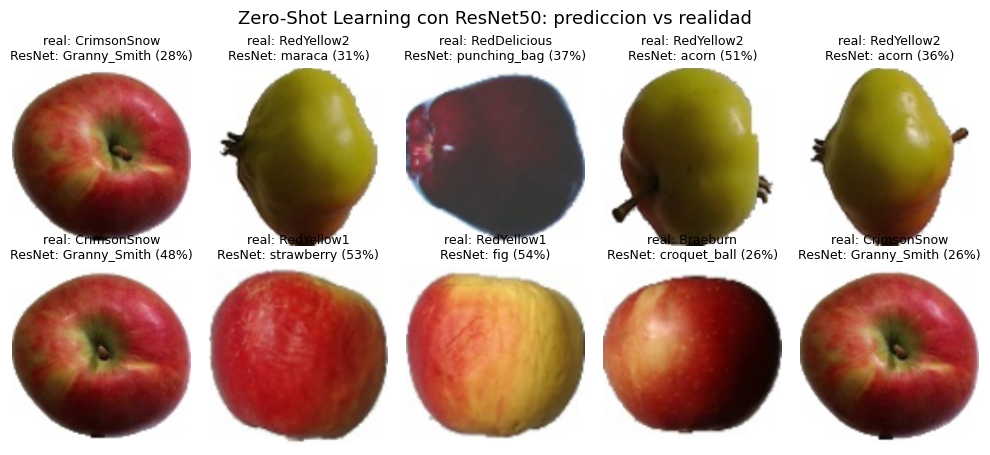

In [20]:
# Vemos 10 casos: que dice ResNet50 frente a la variedad real
muestra = range(10)
etiquetas = [
    f"real: {y_zs_real[i]}\nResNet: {decodificadas[i][0][1]} ({decodificadas[i][0][2]:.0%})"
    for i in muestra
]
plot_imagenes(X_test_224[idx_zs][list(muestra)], etiquetas, n_cols=5,
              titulo="Zero-Shot Learning con ResNet50: prediccion vs realidad")

In [21]:
# Que etiquetas de ImageNet reparte ResNet50 sobre nuestras manzanas
etiquetas_top1 = [d[0][1] for d in decodificadas]
conteo = pd.Series(etiquetas_top1).value_counts()

print(f"Etiquetas distintas que asigna a {N_MUESTRA} manzanas: {len(conteo)}")
print()
print(conteo.head(10).to_string())

Etiquetas distintas que asigna a 300 manzanas: 18

Granny_Smith        108
spaghetti_squash     45
maraca               40
fig                  23
punching_bag         11
strawberry           11
acorn                10
buckeye              10
croquet_ball          9
pomegranate           9


In [22]:
# ¿Cuantas clases de ImageNet son realmente manzanas?
# ImageNet tiene 1000 clases, y solo UNA es una variedad de manzana.
import json
ruta_idx = keras.utils.get_file(
    "imagenet_class_index.json",
    "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json")
indice_imagenet = json.load(open(ruta_idx))

relacionadas = [(k, v[1]) for k, v in indice_imagenet.items()
                if any(p in v[1].lower() for p in ("apple", "granny"))]
print("Clases de ImageNet que tienen que ver con manzanas:")
for k, n in relacionadas:
    print(f"   clase {k}: {n}")

Clases de ImageNet que tienen que ver con manzanas:
   clase 948: Granny_Smith
   clase 953: pineapple
   clase 956: custard_apple


In [23]:
# Como se reparten los aciertos: solo puede acertar las GrannySmith, y por casualidad
es_granny_real = y_zs_real == "GrannySmith"
dice_granny = np.array(etiquetas_top1) == "Granny_Smith"

print(f"Imagenes que SON GrannySmith            : {es_granny_real.sum()}")
print(f"Imagenes que ResNet llama 'Granny_Smith': {dice_granny.sum()}")
print(f"   de las cuales lo son de verdad       : {(es_granny_real & dice_granny).sum()}")
print()
print(f"'Accuracy' si contamos Granny_Smith como acierto: "
      f"{(es_granny_real & dice_granny).sum() / N_MUESTRA:.1%}")

Imagenes que SON GrannySmith            : 20
Imagenes que ResNet llama 'Granny_Smith': 108
   de las cuales lo son de verdad       : 20

'Accuracy' si contamos Granny_Smith como acierto: 6.7%


### ¿Nos sirve este clasificador así tal cual?

**No, y no es cuestión de afinarlo: es imposible por construcción.**

El motivo es contundente: **ImageNet tiene 1000 clases y solo una es una variedad de
manzana**, `Granny_Smith` (la clase 948). Nuestro problema tiene **13 variedades**.
Por tanto ResNet50 *no puede* distinguirlas ni en el mejor de los casos, porque no
tiene vocabulario para hacerlo. Lo máximo que puede hacer es decir "Granny_Smith" a
todas, y acertaría solo las que de verdad lo son.

De hecho es lo que se ve arriba: reparte nuestras manzanas entre un puñado de
etiquetas de ImageNet que ni siquiera son manzanas, y el "accuracy" que se puede
sacar es ridículo.

**La lección**: el zero-shot solo funciona si **las clases que necesitas ya están en
las del modelo original**. Aquí no lo están, así que no queda otra que sustituir la
cabeza y entrenarla con nuestros datos. Que es exactamente lo que hacemos a partir
del Ejercicio 7.

In [24]:
# Liberamos el test a 224x224 y el modelo de zero-shot: no los volvemos a usar
# y ocupan bastante memoria
del X_test_224, y_test_224, X_zs, modelo_zs, preds_zs
gc.collect()
print("Memoria liberada.")

Memoria liberada.


## Transfer Learning

### Ejercicio 7:

Carga la ResNet50 sin cabezas, crea un modelo con el anterior y una cabeza con dos capas densas, una oculta de 300 unidades (con activación "relu") y otra de salida con las unidades que crees necesarias y activación la que consideres. Congela las capas del modelo base (la ResNet50). Define también los hiperparámetros necesarios para compilar y compila el modelo y muestra un summary del mismo.

In [25]:
def construye_modelo(congelar_base=True, con_pesos=True, semilla=SEMILLA):
    """ResNet50 sin cabeza + nuestra cabeza de clasificacion.

    Args:
        congelar_base: si True, la base no se entrena (transfer learning).
        con_pesos: si True carga los pesos de imagenet.
        semilla: para que la cabeza se inicialice igual en cada llamada.
    """
    tf.random.set_seed(semilla)

    base = ResNet50(include_top=False,
                    weights="imagenet" if con_pesos else None,
                    input_shape=(32, 32, 3))
    base.trainable = not congelar_base

    # Cabeza: una oculta de 300 unidades relu + salida de 13 con softmax
    x = layers.Flatten()(base.output)
    x = layers.Dense(300, activation="relu")(x)
    salida = layers.Dense(len(CLASES), activation="softmax")(x)

    return keras.Model(base.input, salida)


model_tl = construye_modelo(congelar_base=True)

**Los hiperparámetros de la cabeza y la compilación**

* **Capa de salida**: 13 unidades (una por variedad) con **`softmax`**, porque es
  clasificación multiclase y queremos una distribución de probabilidad.
* **Loss**: `sparse_categorical_crossentropy`, la que corresponde a multiclase con
  el target como escalar (0..12). Si hubiéramos hecho one-hot sería
  `categorical_crossentropy`.
* **Optimizador**: Adam con `learning_rate=0.001` (el valor por defecto). Como la
  base está **congelada**, solo entrenamos una cabeza nueva desde cero, así que no
  hay riesgo de estropear los pesos heredados y podemos usar un learning rate normal.
* **Métrica**: `accuracy`.

In [26]:
model_tl.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

model_tl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 618,613 (2.36 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
total = model_tl.count_params()
PARAMS_TL = sum(int(tf.size(w)) for w in model_tl.trainable_weights)
print(f"Parametros totales    : {total:,}")
print(f"Parametros entrenables: {PARAMS_TL:,}  ({PARAMS_TL/total:.1%})")
print(f"Parametros heredados  : {total - PARAMS_TL:,}  ({1 - PARAMS_TL/total:.1%})")

Parametros totales    : 24,206,325
Parametros entrenables: 618,613  (2.6%)
Parametros heredados  : 23,587,712  (97.4%)


Ahí está la idea de la unidad en dos números: entrenamos poco más del **2,5%** del
modelo y heredamos el resto. La salida de la base a 32x32 es de `(1, 1, 2048)`, así
que el `Flatten` da 2048 features y la `Dense(300)` cuesta 614.700 pesos.

### Ejercicio 8

Entrena el modelo con nuestros datos de train y muestra la evolución del entrenamiento. Emplea un callback de Earlystopping con patience a 5. Termina de escoger el batch_size y el número de épocas.

Entrenamos con `EarlyStopping` de `patience=5`, como pide el enunciado.

Sobre los que me toca elegir:

* **`batch_size=64`**: un compromiso razonable entre velocidad y estabilidad del
  gradiente, y el mismo que usaremos en el fine-tuning para que la comparación sea
  justa.
* **`epochs=30`** como techo. Con la base congelada solo hay que ajustar la cabeza,
  que converge rápido, así que 30 sobran y el EarlyStopping cortará antes.

In [28]:
early = EarlyStopping(monitor="val_loss", patience=5,
                      restore_best_weights=True, verbose=1)

t0 = time.time()
hist_tl = model_tl.fit(X_train_s, y_train_num,
                       batch_size=64,
                       epochs=30,
                       validation_split=0.2,
                       callbacks=[early],
                       verbose=2)
print(f"\nEntrenamiento: {time.time() - t0:.0f}s")

Epoch 1/30


81/81 - 15s - 184ms/step - accuracy: 0.8897 - loss: 0.6046 - val_accuracy: 0.9852 - val_loss: 0.0526


Epoch 2/30


81/81 - 8s - 99ms/step - accuracy: 0.9969 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0081


Epoch 3/30


...

81/81 - 9s - 111ms/step - accuracy: 1.0000 - loss: 7.6645e-05 - val_accuracy: 1.0000 - val_loss: 2.2406e-04


Epoch 30/30


81/81 - 9s - 109ms/step - accuracy: 1.0000 - loss: 7.1432e-05 - val_accuracy: 1.0000 - val_loss: 2.1177e-04


Restoring model weights from the end of the best epoch: 30.



Entrenamiento: 263s


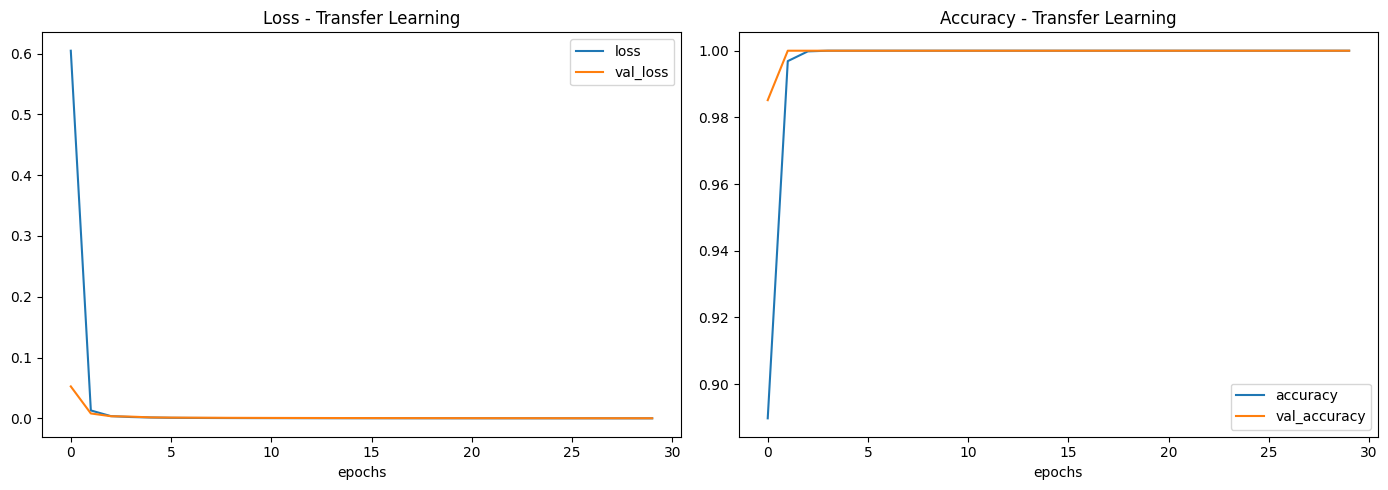

Epocas: 30 | mejor val_loss 0.0002 en epoca 30
En esa epoca: accuracy=1.0000 val_accuracy=1.0000 (diferencia +0.0000)


In [29]:
def pinta_historial(historial, titulo):
    """Pinta loss y accuracy de train y validacion, y resume la mejor epoca."""
    df = pd.DataFrame(historial.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"Loss - {titulo}")
    axes[0].set_xlabel("epochs")

    df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"Accuracy - {titulo}")
    axes[1].set_xlabel("epochs")

    plt.tight_layout()
    plt.show()

    mejor = df["val_loss"].idxmin()
    print(f"Epocas: {len(df)} | mejor val_loss {df['val_loss'].min():.4f} "
          f"en epoca {mejor + 1}")
    print(f"En esa epoca: accuracy={df.loc[mejor, 'accuracy']:.4f} "
          f"val_accuracy={df.loc[mejor, 'val_accuracy']:.4f} "
          f"(diferencia {df.loc[mejor, 'accuracy'] - df.loc[mejor, 'val_accuracy']:+.4f})")
    return df


hist_tl_df = pinta_historial(hist_tl, "Transfer Learning")

### Ejercicio 9

Evalua el modelo contra test y haz un pequeño análisis de las diferencias. Haz un clasification report y muestra la matriz de confusion. Haz un pequeño análisis de errores.

In [30]:
def evalua(modelo, nombre, X, y):
    """Evalua contra test, imprime el report y devuelve metricas y predicciones."""
    loss, acc = modelo.evaluate(X, y, verbose=0)
    print(f"=== {nombre} ===")
    print(f"Loss en test    : {loss:.4f}")
    print(f"Accuracy en test: {acc:.4f}  ({acc:.1%})")
    print(f"Baseline RF     : {BASELINE_RF:.4f}")
    print(f"Azar            : {1/len(CLASES):.4f}")
    print()

    probs = modelo.predict(X, verbose=0)
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)
    print(classification_report(y, pred, target_names=CLASES))
    return {"loss": loss, "accuracy": acc, "pred": pred, "conf": conf}


res_tl = evalua(model_tl, "TRANSFER LEARNING", X_test_pre, y_test_num)

=== TRANSFER LEARNING ===
Loss en test    : 0.3101
Accuracy en test: 0.9166  (91.7%)
Baseline RF     : 0.9831
Azar            : 0.0769



              precision    recall  f1-score   support

    Braeburn       0.72      0.91      0.80       164
 CrimsonSnow       0.99      0.97      0.98       148
     Golden1       1.00      1.00      1.00       160
     Golden2       1.00      1.00      1.00       164
     Golden3       1.00      1.00      1.00       161
 GrannySmith       1.00      1.00      1.00       164
    PinkLady       0.83      0.97      0.90       152
        Red1       0.74      0.96      0.84       164
        Red2       0.83      0.83      0.83       164
        Red3       0.89      0.41      0.56       144
RedDelicious       1.00      1.00      1.00       166
  RedYellow1       1.00      0.79      0.88       164
  RedYellow2       1.00      1.00      1.00       219

    accuracy                           0.92      2134
   macro avg       0.92      0.91      0.91      2134
weighted avg       0.93      0.92      0.91      2134



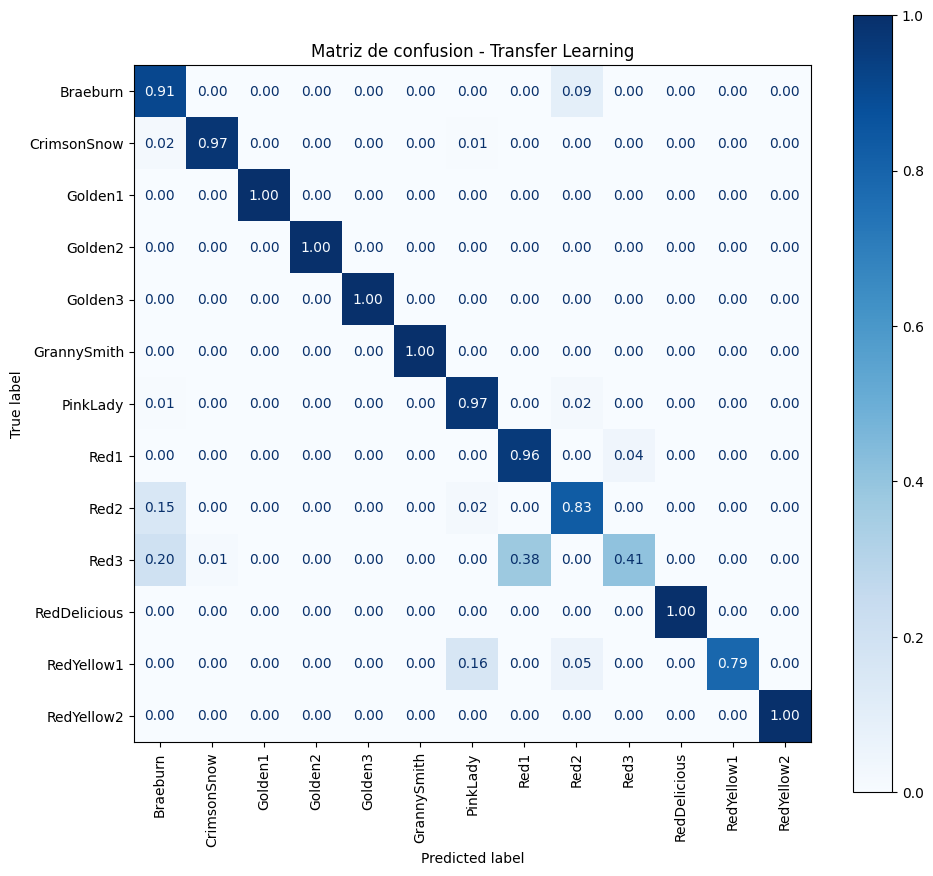

In [31]:
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, res_tl["pred"], display_labels=CLASES, cmap="Blues",
    normalize="true", values_format=".2f", xticks_rotation=90, ax=ax)
ax.set_title("Matriz de confusion - Transfer Learning")
plt.tight_layout()
plt.show()

In [32]:
# Analisis de errores: que pares de variedades se confunden mas
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test_num, res_tl["pred"])
confusiones = []
for i in range(len(CLASES)):
    for j in range(len(CLASES)):
        if i != j and matriz[i, j] > 0:
            confusiones.append({
                "real": CLASES[i], "predicha": CLASES[j],
                "n": int(matriz[i, j]),
                "pct_de_su_clase": round(100 * matriz[i, j] / matriz[i].sum(), 1)})

df_conf = pd.DataFrame(confusiones).sort_values("n", ascending=False).reset_index(drop=True)
print(f"Errores totales: {(res_tl['pred'] != y_test_num).sum()} de {len(y_test_num)}")
print("\nLos 10 pares que mas se confunden:")
df_conf.head(10)

Errores totales: 178 de 2134

Los 10 pares que mas se confunden:


,real,predicha,n,pct_de_su_clase
0,Red3,Red1,54,37.5
1,Red3,Braeburn,29,20.1
2,RedYellow1,PinkLady,26,15.9
3,Red2,Braeburn,25,15.2
4,Braeburn,Red2,15,9.1
5,RedYellow1,Red2,9,5.5
6,Red1,Red3,7,4.3
7,PinkLady,Red2,3,2.0
8,CrimsonSnow,Braeburn,3,2.0
9,Red2,PinkLady,3,1.8


Confianza media en aciertos: 98.1%
Confianza media en errores : 76.9%


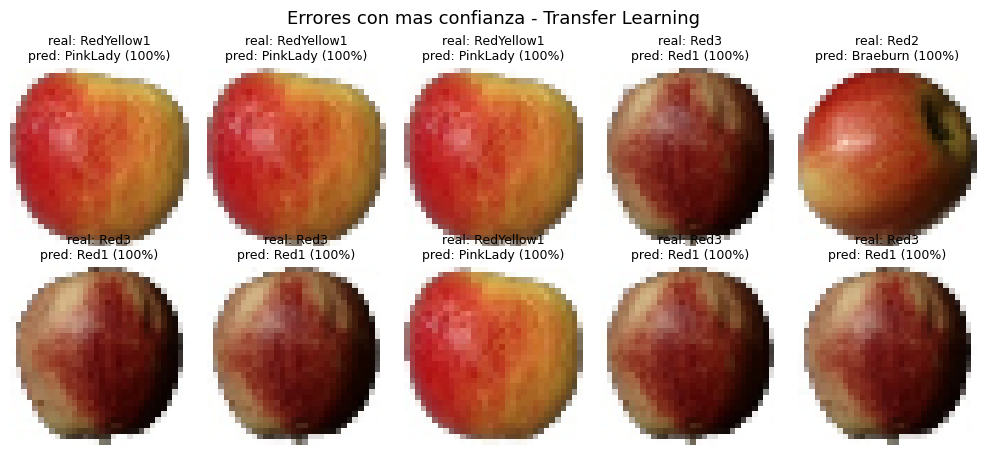

In [33]:
# Vemos algunos errores con la confianza que tenia el modelo
errores = np.where(res_tl["pred"] != y_test_num)[0]
print(f"Confianza media en aciertos: {res_tl['conf'][res_tl['pred'] == y_test_num].mean():.1%}")
print(f"Confianza media en errores : {res_tl['conf'][errores].mean():.1%}")

if len(errores):
    peores = errores[np.argsort(-res_tl["conf"][errores])][:10]
    etiquetas = [f"real: {numero_a_clase[y_test_num[i]]}\n"
                 f"pred: {numero_a_clase[res_tl['pred'][i]]} ({res_tl['conf'][i]:.0%})"
                 for i in peores]
    plot_imagenes(X_test[peores], etiquetas, n_cols=5,
                  titulo="Errores con mas confianza - Transfer Learning")

**Lectura del transfer learning**

Accuracy en test: **91,66%**, con 178 errores de 2.134. Parece un buen resultado...
hasta que se compara con el baseline:

| modelo | accuracy test |
|---|---|
| azar | 7,7% |
| **RandomForest sobre píxeles planos** | **98,31%** |
| ResNet50 transfer learning | 91,66% |

**El RandomForest gana por casi 7 puntos.** Un extractor de features entrenado con más
de un millón de imágenes pierde contra un modelo que solo mira píxeles sueltos.

Y hay una segunda señal, más sutil pero igual de importante. Mira el historial: la
**`val_accuracy` llega a 1.0000** y la `val_loss` baja hasta 0.0002, mejorando hasta la
última época. Consecuencia: **el `EarlyStopping` nunca se dispara** y agota las 30
épocas, porque desde su punto de vista el modelo no ha dejado de mejorar ni una vez.
Pero el test se queda en el 91,66%.

Es exactamente el problema de los fotogramas gemelos que diagnosticamos en el Ejercicio
3: el `validation_split` coge un 20% de train lleno de gemelos del otro 80%, así que
**la validación es un espejismo**. Y no es un detalle cosmético: significa que el
callback que debería decidir cuándo parar está tomando la decisión con información
falsa.

La lección práctica: en este dataset, cualquier decisión tomada mirando la validación
está mal informada. Habría que hacer el split **por secuencia de rotación**, no por
fotograma.

Sobre los errores: la confianza media es del **98,1% en los aciertos** frente al 76,9%
en los errores, así que el softmax sí discrimina. Y los fallos se concentran en las
variedades rojas: `Red3` es la peor con diferencia (f1 de 0.562) y se confunde con
`Braeburn` y `Red1`. Tiene sentido, son manzanas rojas de tamaño y forma parecidos que
a 32x32 se distinguen por matices de tono.

## Fine Tuning

### Ejercicio 10

Vuelve a descargar el modelo ResNet50 pero sin pesos entrenados, ni cabeza, crea el mismo modelo personalizado que en el ejercicio 7, compila y muestra el summary.

> **Fe de erratas del enunciado.** El Ejercicio 10 pide cargar la ResNet50 *"sin
> pesos entrenados"*. Eso no es fine-tuning: si los pesos son aleatorios no hay nada
> que "afinar", estaríamos entrenando una ResNet50 desde cero (y con 6.400 imágenes
> eso no va a ningún sitio).
>
> El propio workout de la unidad lleva una nota corrigiéndolo: *"IMPORTANTE, para
> hacer Fine-tuning SÍ que necesitamos traernos los pesos de la red, de lo contrario
> no estamos haciendo ajuste fino de nada"*.
>
> Así que cargamos con **`weights="imagenet"`** y descongelamos la base.

In [34]:
model_ft = construye_modelo(congelar_base=False, con_pesos=True)

**La compilación del fine-tuning: bajamos el learning rate**

Aquí sí cambio un hiperparámetro respecto al Ejercicio 7, y es deliberado. Con la
base descongelada estamos modificando 23 millones de pesos que ya son buenos, y un
learning rate alto los destruye en las primeras iteraciones (*catastrophic
forgetting*). Se reconoce porque la `val_loss` de la primera época se dispara a
valores absurdos.

Usamos **`learning_rate=1e-4`**, diez veces menor que en el transfer.

*(Nota: en la práctica obligatoria de esta unidad hacemos el fine-tuning de la forma
recomendada, que es partir de la cabeza ya entrenada y luego descongelar. Aquí
seguimos el enunciado, que pide un modelo nuevo.)*

In [35]:
model_ft.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

model_ft.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 24,206,325 (92.34 MB)

 Trainable params: 24,153,205 (92.14 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [36]:
total = model_ft.count_params()
PARAMS_FT = sum(int(tf.size(w)) for w in model_ft.trainable_weights)
print(f"Parametros entrenables: {PARAMS_FT:,} de {total:,} ({PARAMS_FT/total:.1%})")
print(f"En el transfer eran   : {PARAMS_TL:,} ({PARAMS_TL/total:.1%})")
print(f"\nSon {PARAMS_FT/PARAMS_TL:.0f} veces mas parametros que entrenar.")

Parametros entrenables: 24,153,205 de 24,206,325 (99.8%)
En el transfer eran   : 618,613 (2.6%)

Son 39 veces mas parametros que entrenar.


### Ejercicio 11
Entrena con batch_size a 64 y 60 épocas, con un EarlyStopping de patience a 10 (ahora el entrenamiento es sensiblemente más largo, así que tómate un descanso). Muestra la evolución y da una posible justificación a emplear tantas épocas de partida.

Entrenamos como pide el enunciado: `batch_size=64`, 60 épocas y `EarlyStopping` con
`patience=10`.

**¿Por qué tantas épocas de partida?** Por dos razones que se refuerzan:

1. En el transfer solo ajustábamos una cabeza pequeña sobre features ya buenas, y eso
   converge en pocas épocas. Aquí estamos moviendo los 23 millones de pesos de toda
   la red, y con un learning rate diez veces menor: cada época avanza mucho menos, así
   que hacen falta muchas más.
2. La `patience` alta (10 frente a 5) va en el mismo sentido. El fine-tuning es un
   proceso más ruidoso, con mesetas de las que el modelo sale al cabo de varias
   épocas. Con paciencia baja cortaríamos en un bache y nos quedaríamos sin ver la
   mejora.

El precio es el tiempo: cada época cuesta unos 70 segundos frente a los ~9 del
transfer, porque hay que calcular gradientes para toda la red y no solo para la
cabeza. De ahí el "tómate un descanso" del enunciado.

In [37]:
early_ft = EarlyStopping(monitor="val_loss", patience=10,
                         restore_best_weights=True, verbose=1)

t0 = time.time()
hist_ft = model_ft.fit(X_train_s, y_train_num,
                       batch_size=64,
                       epochs=60,
                       validation_split=0.2,
                       callbacks=[early_ft],
                       verbose=2)
print(f"\nEntrenamiento: {time.time() - t0:.0f}s "
      f"({(time.time() - t0)/60:.0f} min)")

Epoch 1/60


81/81 - 88s - 1s/step - accuracy: 0.8569 - loss: 0.5251 - val_accuracy: 0.5964 - val_loss: 1.5298


Epoch 2/60


81/81 - 57s - 700ms/step - accuracy: 0.9930 - loss: 0.0351 - val_accuracy: 0.9126 - val_loss: 0.3169


Epoch 3/60


...

81/81 - 58s - 718ms/step - accuracy: 1.0000 - loss: 8.9086e-06 - val_accuracy: 1.0000 - val_loss: 1.1046e-04


Epoch 60/60


81/81 - 58s - 722ms/step - accuracy: 1.0000 - loss: 8.4814e-06 - val_accuracy: 1.0000 - val_loss: 1.0807e-04


Restoring model weights from the end of the best epoch: 60.



Entrenamiento: 3501s (58 min)


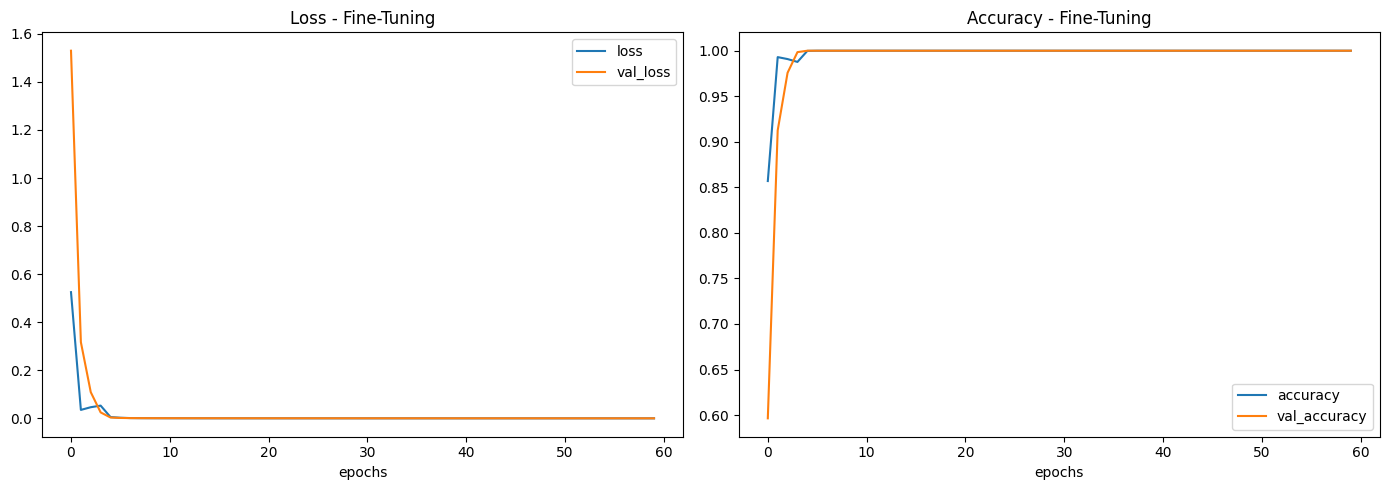

Epocas: 60 | mejor val_loss 0.0001 en epoca 60
En esa epoca: accuracy=1.0000 val_accuracy=1.0000 (diferencia +0.0000)


In [38]:
hist_ft_df = pinta_historial(hist_ft, "Fine-Tuning")

### Ejercicio 12

Muestra la evaluación contra el test, el informe de clasificación  y la matriz de confusión. Compara los resultados con los del ejercicio 9.

In [39]:
res_ft = evalua(model_ft, "FINE-TUNING", X_test_pre, y_test_num)

=== FINE-TUNING ===
Loss en test    : 0.2412
Accuracy en test: 0.9405  (94.0%)
Baseline RF     : 0.9831
Azar            : 0.0769



              precision    recall  f1-score   support

    Braeburn       0.77      0.75      0.76       164
 CrimsonSnow       1.00      0.97      0.98       148
     Golden1       0.98      1.00      0.99       160
     Golden2       1.00      0.96      0.98       164
     Golden3       0.94      0.98      0.96       161
 GrannySmith       0.99      0.98      0.98       164
    PinkLady       0.96      1.00      0.98       152
        Red1       0.92      0.91      0.92       164
        Red2       0.76      0.87      0.81       164
        Red3       0.91      0.94      0.93       144
RedDelicious       1.00      1.00      1.00       166
  RedYellow1       1.00      0.86      0.92       164
  RedYellow2       1.00      1.00      1.00       219

    accuracy                           0.94      2134
   macro avg       0.94      0.94      0.94      2134
weighted avg       0.94      0.94      0.94      2134



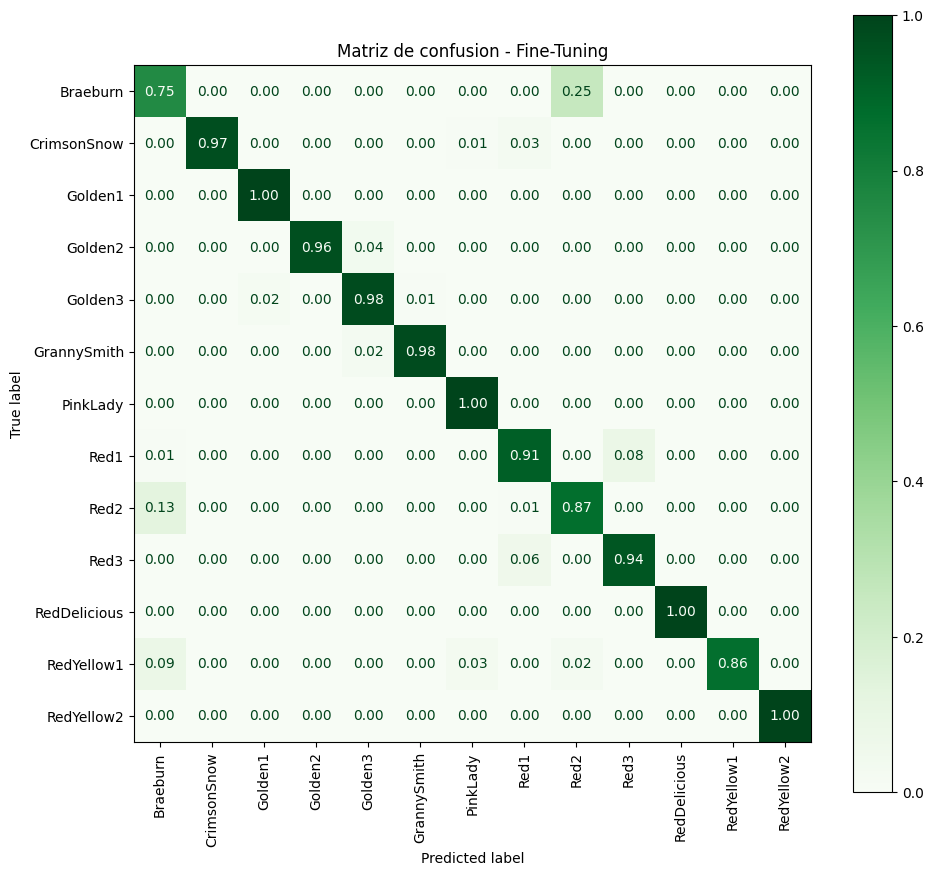

In [40]:
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, res_ft["pred"], display_labels=CLASES, cmap="Greens",
    normalize="true", values_format=".2f", xticks_rotation=90, ax=ax)
ax.set_title("Matriz de confusion - Fine-Tuning")
plt.tight_layout()
plt.show()

In [41]:
# Comparativa de los tres enfoques
comparativa = pd.DataFrame([
    {"enfoque": "Baseline RandomForest", "params_entrenados": 0,
     "epocas": None, "accuracy_test": round(BASELINE_RF, 4)},
    {"enfoque": "Transfer Learning", "params_entrenados": PARAMS_TL,
     "epocas": len(hist_tl_df), "accuracy_test": round(res_tl["accuracy"], 4)},
    {"enfoque": "Fine-Tuning", "params_entrenados": PARAMS_FT,
     "epocas": len(hist_ft_df), "accuracy_test": round(res_ft["accuracy"], 4)},
])
comparativa

,enfoque,params_entrenados,epocas,accuracy_test
0,Baseline RandomForest,0,NaN,0.9831
1,Transfer Learning,618613,30.0,0.9166
2,Fine-Tuning,24153205,60.0,0.9405


In [42]:
# f1 por clase de los dos modelos preentrenados
from sklearn.metrics import f1_score

df_f1 = pd.DataFrame({
    "clase": CLASES,
    "f1_transfer": np.round(f1_score(y_test_num, res_tl["pred"], average=None), 3),
    "f1_finetuning": np.round(f1_score(y_test_num, res_ft["pred"], average=None), 3),
})
df_f1["diferencia"] = (df_f1["f1_finetuning"] - df_f1["f1_transfer"]).round(3)
df_f1.sort_values("diferencia", ascending=False).reset_index(drop=True)

,clase,f1_transfer,f1_finetuning,diferencia
0,Red3,0.562,0.928,0.366
1,PinkLady,0.897,0.981,0.084
2,Red1,0.837,0.917,0.080
3,RedYellow1,0.881,0.925,0.044
4,CrimsonSnow,0.980,0.983,0.003
5,RedDelicious,1.000,1.000,0.000
6,RedYellow2,1.000,1.000,0.000
7,Golden1,1.000,0.991,-0.009
8,GrannySmith,1.000,0.985,-0.015
9,Golden2,1.000,0.981,-0.019


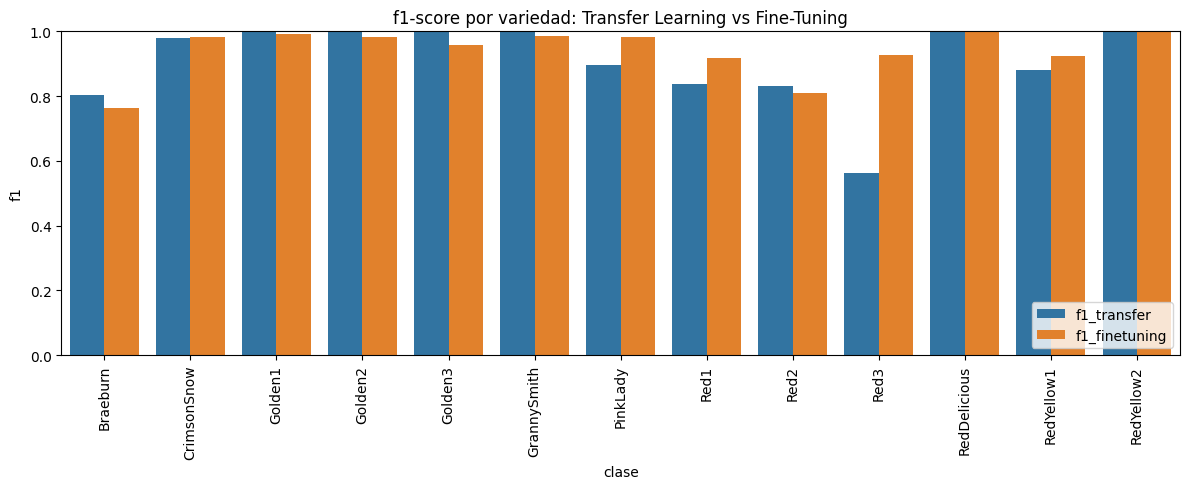

In [43]:
df_plot = df_f1.melt(id_vars="clase", value_vars=["f1_transfer", "f1_finetuning"],
                     var_name="enfoque", value_name="f1")

plt.figure(figsize=(12, 5))
sns.barplot(data=df_plot, x="clase", y="f1", hue="enfoque")
plt.title("f1-score por variedad: Transfer Learning vs Fine-Tuning")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lectura del fine-tuning y comparación con el Ejercicio 9**

Accuracy en test: **94,05%**, frente al 91,66% del transfer. **2,4 puntos de mejora**,
y también baja la loss (0.2412 frente a 0.3101). El fine-tuning gana, aunque le cuesta
entrenar **39 veces más parámetros** y unas 8 veces más tiempo por época.

Tres observaciones sobre el proceso:

* **La primera época acusa el descongelado**: `val_accuracy` del 59,6% y `val_loss` de
  **1.5298**, muy por encima de donde acabará. Es el efecto de mover 23 millones de
  pesos preentrenados con una cabeza recién inicializada al azar. Se recupera ya en la
  segunda época (91,3%) gracias a que bajamos el `learning_rate` a 1e-4, pero el bache
  se ve. En la práctica obligatoria de esta unidad lo evitamos entrenando primero la
  cabeza y descongelando después, y allí la primera época ya sale mejor que el punto de
  partida.
* **Agotó las 60 épocas**, con la mejor `val_loss` en la última (0.0001). Igual que en
  el transfer, el `EarlyStopping` no llegó a dispararse: la validación contaminada nunca
  dejó de "mejorar". Así que la `patience=10` del enunciado ni siquiera entró en juego,
  y el modelo todavía estaba mejorando cuando llegó al techo de épocas.
* Por eso mismo **no sabemos si 60 épocas eran suficientes**. Con una validación fiable
  podríamos responderlo; con esta, no.

Por clases, el fine-tuning **ataca justo donde el transfer fallaba**:

| clase | f1 transfer | f1 fine-tuning | diferencia |
|---|---|---|---|
| Red3 | 0.562 | **0.928** | **+0,366** |
| PinkLady | 0.897 | 0.981 | +0,084 |
| Red1 | 0.837 | 0.917 | +0,080 |
| RedYellow1 | 0.881 | 0.925 | +0,044 |
| ... | | | |
| Braeburn | 0.803 | 0.762 | -0,041 |
| Golden3 | 1.000 | 0.957 | -0,043 |

`Red3` pasa de 0.562 a 0.928, una mejora enorme, y las otras variedades rojas y rosadas
también ganan. En cambio pierde algo en clases que ya estaban en 1.000. Es decir: el
fine-tuning **redistribuye** los aciertos hacia las clases difíciles, y de paso sube la
media.

Pero el resumen honesto sigue siendo el mismo: **ninguno de los dos enfoques bate al
RandomForest** (98,31%) en este problema.

***
## Conclusiones de los ejercicios

**Los resultados, de un vistazo**

| enfoque | accuracy test | params entrenados |
|---|---|---|
| azar | 7,7% | — |
| ResNet50 zero-shot | 6,7% | 0 |
| ResNet50 transfer learning | 91,66% | 618.613 |
| ResNet50 fine-tuning | 94,05% | 24.153.205 |
| **RandomForest sobre píxeles planos** | **98,31%** | 0 |

**Sobre el zero-shot (Ejercicio 6)**

1. No sirve, y el motivo es estructural: **ImageNet tiene 1000 clases y solo una es una
   variedad de manzana**, `Granny_Smith` (la 948). Nosotros necesitamos 13. El modelo no
   tiene vocabulario para nuestro problema.
2. Se ve en los datos: de 300 manzanas, ResNet50 reparte **18 etiquetas distintas**, y
   las más frecuentes son `Granny_Smith` (108), `spaghetti_squash` (45) y `maraca` (40).
   Acierta las 20 `GrannySmith` reales y nada más: un **6,7%**, por debajo incluso del
   azar.
3. La conclusión general: el zero-shot solo funciona **si tus clases ya están entre las
   del modelo original**.

**Transfer learning frente a fine-tuning**

4. El **fine-tuning gana** (94,05% frente a 91,66%), como dice la teoría de la unidad.
   Le cuesta 39 veces más parámetros y ~8 veces más tiempo por época.
5. Lo interesante es *cómo* gana: **redistribuyendo**. `Red3` sube de f1 0.562 a 0.928
   (+0,366) y las demás variedades rojas también, a costa de perder unas centésimas en
   clases que ya estaban perfectas. El transfer learning con la base congelada no podía
   aprender los matices de tono que separan `Red1`, `Red2` y `Red3`; el fine-tuning sí.
6. En el fine-tuning bajamos el learning rate a 1e-4 a propósito. Aun así la primera
   época acusa el descongelado (`val_loss` de 1.53). Es la razón por la que en la
   práctica obligatoria hacemos el fine-tuning en el orden correcto: cabeza primero,
   descongelado después.
7. El **preprocesado propio de cada modelo no es opcional**: ResNet50 espera las medias
   de ImageNet restadas en orden BGR (rango de -124 a +151), no [0, 1] como hacíamos en
   la Unidad 1.
8. La **errata del Ejercicio 10** importa: sin los pesos preentrenados no habría
   fine-tuning, sería entrenar una ResNet50 desde cero con 6.400 imágenes.

**La conclusión incómoda: aquí el transfer learning no merece la pena**

9. El **RandomForest sobre píxeles planos gana a los dos modelos preentrenados**, por
   4,3 puntos al fine-tuning y por 6,7 al transfer, sin entrenar ni un parámetro de red
   y en segundos.
10. La razón está en el dataset, no en los modelos. Apple 360 es **de laboratorio**:
    fondo blanco, fruta centrada, iluminación uniforme. En esas condiciones la posición
    de cada píxel es informativa por sí sola y un modelo tabular no está en desventaja.
    Las features de ImageNet están pensadas para fotos naturales con fondos complejos, y
    a 32x32 la salida de ResNet50 se comprime a un único punto espacial de 2048 valores.
11. Es un ejemplo práctico de la **transferencia negativa** que menciona la teoría de la
    unidad. Y justifica tener un baseline: sin él habríamos celebrado un "94% frente al
    7,7% del azar" sin saber que un modelo trivial hacía mejor el trabajo.

**Sobre el dataset: la lección más transferible de todas**

12. La validación cruzada dentro de train da **1.0000**, un resultado imposible que
    destapa el problema: Apple 360 contiene **fotogramas casi idénticos de la misma
    fruta girando**. Medido sobre `Braeburn`: 471 de 492 imágenes tienen un gemelo a
    distancia menor de 500, y la distancia media al conjunto de test es **siete veces
    mayor** (1790 frente a 265). Los nombres de fichero lo confirman: son frames
    numerados consecutivamente, y el reparto train/test se hizo cortando por número.
13. La consecuencia es grave y afecta a los dos modelos: la `val_accuracy` llega a
    **1.0000** en ambos, así que **el `EarlyStopping` nunca se dispara** y los dos
    entrenamientos agotan su techo de épocas. El callback que debía decidir cuándo parar
    estaba leyendo una métrica falsa.
14. Lo correcto sería partir **por secuencia de rotación**, no por fotograma. Y la
    lección general: un `1.0000` perfecto nunca es una buena noticia, es una invitación a
    mirar los datos. Esto no se detecta mirando métricas.